In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)
n = 9800  # 模拟约9800行

# 类别层级
categories = {
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Paper', 'Binders', 'Envelopes',
                   'Storage', 'Labels', 'Art', 'Supplies',
                   'Fasteners', 'Appliances'],
    'Technology': ['Phones', 'Accessories', 'Machines', 'Copiers']
}
regions = ['East', 'West', 'Central', 'South']
segments = ['Consumer', 'Corporate', 'Home Office']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

# 生成基础数据
start = datetime(2015, 1, 1)
order_dates = sorted([start + timedelta(days=np.random.randint(0, 1460)) for _ in range(n)])
cat_list = np.random.choice(list(categories.keys()), n, p=[0.25, 0.55, 0.2])
subcat_list = [np.random.choice(categories[c]) for c in cat_list]
ship_days = np.random.choice([1, 2, 3, 5, 7], n, p=[0.05, 0.15, 0.2, 0.4, 0.2])

sales_base = {
    'Chairs': 350, 'Tables': 500, 'Bookcases': 400, 'Furnishings': 80,
    'Paper': 40, 'Binders': 60, 'Envelopes': 30,
    'Storage': 120, 'Labels': 25, 'Art': 35,
    'Supplies': 70, 'Fasteners': 20, 'Appliances': 150,
    'Phones': 400, 'Accessories': 120,
    'Machines': 800, 'Copiers': 1200
}

sales = []
quantity = np.random.randint(1, 15, n)
discount = np.random.choice([0, 0, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7], n)

for i in range(n):
    base = sales_base[subcat_list[i]]
    s = np.random.exponential(base) * quantity[i] * (1 - discount[i])
    sales.append(round(max(s, 5), 2))

profit = [round(sales[i] * np.random.normal(0.12, 0.15), 2) for i in range(n)]

df = pd.DataFrame({
    'Row ID': range(1, n+1),
    'Order ID': [f'US-{2023 + (d.year-2015)}-{100000+i}' for i, d in enumerate(order_dates)],
    'Order Date': order_dates,
    'Ship Date': [order_dates[i] + timedelta(days=int(ship_days[i])) for i in range(n)],
    'Ship Mode': np.random.choice(ship_modes, n),
    'Customer ID': [f'AB-100{np.random.randint(10, 99)}' for _ in range(n)],
    'Segment': np.random.choice(segments, n),
    'Country': 'United States',
    'State': np.random.choice(['California', 'New York', 'Texas',
                              'Pennsylvania', 'Washington'], n),
    'Postal Code': np.random.randint(10000, 99999, n),
    'Region': np.random.choice(regions, n),
    'Product ID': [f'FUR-TA-100{np.random.randint(100,999)}' for _ in range(n)],
    'Category': cat_list,
    'Sub-Category': subcat_list,
    'Product Name': [f'{subcat_list[i]} Product {np.random.randint(1,50)}' for i in range(n)],
    'Sales': sales,
    'Quantity': quantity,
    'Discount': discount,
    'Profit': profit,
})

df.to_csv('train.csv', index=False)
print(f'✅ 生成完成：{len(df)} 行 × {len(df.columns)} 列')
print(f'📅 时间范围：{df["Order Date"].min().date()} ~ {df["Order Date"].max().date()}')
print(f'🏷  SKU数量：{df["Product ID"].nunique()}')
print(f'💰 总销售额：${df["Sales"].sum():,.2f}')

✅ 生成完成：9800 行 × 19 列
📅 时间范围：2015-01-01 ~ 2018-12-30
🏷  SKU数量：899
💰 总销售额：$13,389,314.05


In [4]:
'''
订单日期（Order Date）是不是 datetime 类型？不是的话要转
哪些字段是数值型（销量/销售额/利润/折扣），哪些是类别型（地区/品类/ Ship Mode）
SKU（Product ID）有多少个 —— 这决定了你库存分析的颗粒度
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('train.csv')

# === 基本信息 ===
print(f"行数: {df.shape[0]}")
print(f"列数: {df.shape[1]}")
print(f"\n字段列表:\n{df.columns.tolist()}")
print(f"\n数据类型:\n{df.dtypes}")

# === 前5行 ===
df.head()

# === 每列唯一值数量 ===
print("\n每列唯一值数量:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()}")

行数: 9800
列数: 19

字段列表:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

数据类型:
Row ID            int64
Order ID            str
Order Date          str
Ship Date           str
Ship Mode           str
Customer ID         str
Segment             str
Country             str
State               str
Postal Code       int64
Region              str
Product ID          str
Category            str
Sub-Category        str
Product Name        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

每列唯一值数量:
  Row ID: 9800
  Order ID: 9800
  Order Date: 1458
  Ship Date: 1463
  Ship Mode: 4
  Customer ID: 89
  Segment: 3
  Country: 1
  State: 5
  Postal Code: 9281
  Region: 4
  Product ID: 899
  Category: 3
  Sub-Category: 17
  Product Name: 833
  Sales: 9079

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9800 non-null   int64  
 1   Order ID      9800 non-null   str    
 2   Order Date    9800 non-null   str    
 3   Ship Date     9800 non-null   str    
 4   Ship Mode     9800 non-null   str    
 5   Customer ID   9800 non-null   str    
 6   Segment       9800 non-null   str    
 7   Country       9800 non-null   str    
 8   State         9800 non-null   str    
 9   Postal Code   9800 non-null   int64  
 10  Region        9800 non-null   str    
 11  Product ID    9800 non-null   str    
 12  Category      9800 non-null   str    
 13  Sub-Category  9800 non-null   str    
 14  Product Name  9800 non-null   str    
 15  Sales         9800 non-null   float64
 16  Quantity      9800 non-null   int64  
 17  Discount      9800 non-null   float64
 18  Profit        9800 non-null   float64
d

In [7]:
'''
Postal Code 有缺失：正常，用 City 字段补充即可，库存分析不需要邮编
利润为负：是正常业务现象（打折亏损单），不要删，后面要分析哪些品类亏钱
发货时长为负：发货日期早于下单日期 = 脏数据，删掉这些行
'''

print("缺失值统计:")
missing = df.isnull().sum()
print(missing[missing > 0])

# === 重复行检查 ===
print(f"\n重复行数: {df.duplicated().sum()}")

# === 日期格式转换（关键！）===
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# 提取日期维度
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order MonthStr'] = df['Order Date'].dt.strftime('%Y-%m')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

# 计算发货时长（天）
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# === 异常值检查 ===
print("\n数值列描述统计（看最小值有没有负数）:")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())

# === 处理（按需）===
# 删重复
df = df.drop_duplicates()
# 如果有销售额为0或负数的行，先标记再决定
print(f"\n销售额 <= 0 的行数: {(df['Sales'] <= 0).sum()}")
print(f"利润为负的行数: {(df['Profit'] < 0).sum()}")

缺失值统计:
Series([], dtype: int64)

重复行数: 0

数值列描述统计（看最小值有没有负数）:
              Sales     Quantity     Discount        Profit
count   9800.000000  9800.000000  9800.000000   9800.000000
mean    1366.256536     7.467347     0.248439    165.265905
std     3340.670707     4.003029     0.236616    667.866033
min        5.000000     1.000000     0.000000  -7476.730000
25%       82.115000     4.000000     0.000000      0.910000
50%      301.820000     7.000000     0.200000     19.040000
75%     1082.982500    11.000000     0.400000    108.335000
max    57041.100000    14.000000     0.700000  14763.360000

销售额 <= 0 的行数: 0
利润为负的行数: 2120


In [8]:
#描述性统计
'''
哪个品类卖得最好？利润最高？利润率最高？
哪个地区贡献最大（销售额与利润）？有没有地区是亏钱的？
主要发货方式是什么？平均几天能发出去？
'''
# === 核心指标总览 ===
print(f"总销售额: ${df['Sales'].sum():,.2f}")
print(f"总利润: ${df['Profit'].sum():,.2f}")
print(f"总销量: {df['Quantity'].sum():,} 件")
print(f"订单数: {df['Order ID'].nunique():,} 单")
print(f"客户数: {df['Customer ID'].nunique():,} 人")
print(f"SKU数: {df['Product ID'].nunique():,} 个")
print(f"时间跨度: {df['Order Date'].min().date()} ~ {df['Order Date'].max().date()}")
print(f"整体利润率: {df['Profit'].sum() / df['Sales'].sum() * 100:.1f}%")

# === 按维度拆分统计 ===
# 按品类 Category
print("\n【按品类】")
cat_stats = df.groupby('Category').agg(
    销售额=('Sales','sum'),
    利润=('Profit','sum'),
    销量=('Quantity','sum'),
    订单数=('Order ID','nunique')
).round(2)
cat_stats['利润率'] = (cat_stats['利润'] / cat_stats['销售额'] * 100).round(1)
print(cat_stats.sort_values('销售额', ascending=False))

# 按地区 Region
print("\n【按地区】")
region_stats = df.groupby('Region').agg(
    销售额=('Sales','sum'),
    利润=('Profit','sum')
).round(2)
region_stats['利润率'] = (region_stats['利润'] / region_stats['销售额'] * 100).round(1)
print(region_stats.sort_values('销售额', ascending=False))

# 按发货方式 Ship Mode
print("\n【按发货方式】")
ship_stats = df.groupby('Ship Mode').agg(
    订单数=('Order ID','nunique'),
    平均发货天数=('Ship Days','mean')
).round(1)
print(ship_stats)
'''
Technology品类卖的最好；利润最高；Furniture利润率最高
West地区贡献最大；无地区亏钱
发货方式很平均，平均4天
市场格局：West地区贡献了
'''

总销售额: $13,389,314.05
总利润: $1,619,605.87
总销量: 73,180 件
订单数: 9,800 单
客户数: 89 人
SKU数: 899 个
时间跨度: 2015-01-01 ~ 2018-12-30
整体利润率: 12.1%

【按品类】
                        销售额         利润     销量   订单数   利润率
Category                                                 
Technology       7103890.12  836467.42  14361  1945  11.8
Furniture        4500516.39  572358.99  18585  2468  12.7
Office Supplies  1784907.54  210779.46  40234  5387  11.8

【按地区】
                销售额         利润   利润率
Region                              
West     3563422.27  448466.36  12.6
Central  3328528.01  394655.00  11.9
South    3290778.09  422638.45  12.8
East     3206585.68  353846.06  11.0

【按发货方式】
                 订单数  平均发货天数
Ship Mode                   
First Class     2466     4.3
Same Day        2377     4.3
Second Class    2433     4.3
Standard Class  2524     4.3


In [15]:
# ===== 洞察用关键数字预计算 =====
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = total_profit / total_sales * 100

# 地区
region_sales_pct = (df.groupby('Region')['Sales'].sum().sort_values(ascending=False) / total_sales * 100).round(1)
top_region, top_region_pct = region_sales_pct.index[0], region_sales_pct.iloc[0]

# 品类占比和利润率
cat_sales_pct = (df.groupby('Category')['Sales'].sum().sort_values(ascending=False) / total_sales * 100).round(1)
top_cat, top_cat_pct = cat_sales_pct.index[0], cat_sales_pct.iloc[0]

cat_margin = (df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum() * 100).sort_values(ascending=False).round(1)

# Q4占比
quarter_total = df.groupby('Order Quarter')['Sales'].sum()
q4_ratio = (quarter_total.filter(like='Q4').sum() / quarter_total.sum() * 100).round(1)

# 峰值月/低谷月
month_total = df.groupby('Order Month')['Sales'].sum()
peak_month, low_month = month_total.idxmax(), month_total.idxmin()

# 帕累托：Top20%产品贡献多少销售额
product_sales = df.groupby('Product ID')['Sales'].sum().sort_values(ascending=False)
top20_count = int(len(product_sales) * 0.2)
pareto_pct = (product_sales.head(top20_count).sum() / total_sales * 100).round(1)

【年度趋势】
                   销售额         利润   订单数  客户数   利润率  销售额同比  利润同比
Order Year                                                     
2015        2966813.01  369714.65  2344   89  12.5    NaN   NaN
2016        3493809.02  435483.28  2477   89  12.5   17.8  17.8
2017        3498324.70  432744.69  2477   89  12.4    0.1  -0.6
2018        3430367.32  381663.25  2502   89  11.1   -1.9 -11.8


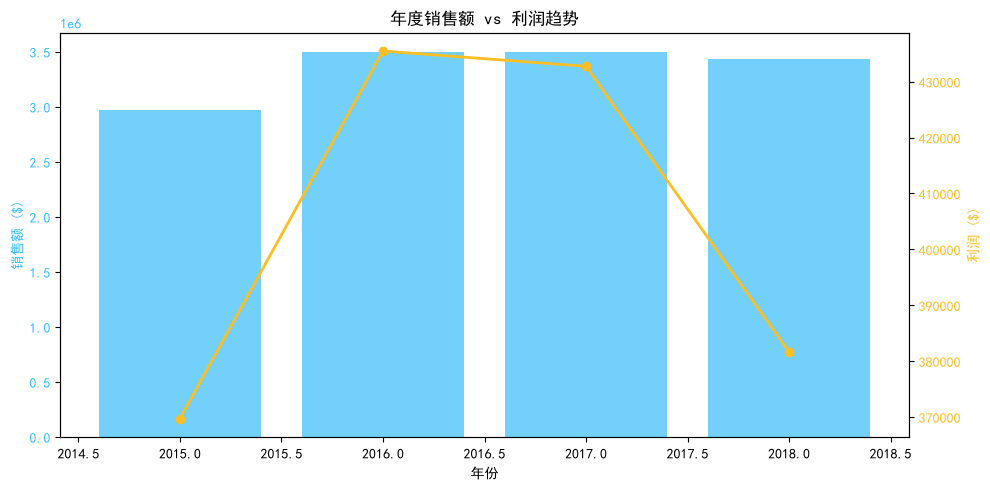


【各年各季度销售额】
Order Quarter    2015Q1    2015Q2    2015Q3    2015Q4    2016Q1    2016Q2  \
Order Year                                                                  
2015           928741.0  670683.0  781243.0  586147.0       NaN       NaN   
2016                NaN       NaN       NaN       NaN  880238.0  782631.0   
2017                NaN       NaN       NaN       NaN       NaN       NaN   
2018                NaN       NaN       NaN       NaN       NaN       NaN   

Order Quarter    2016Q3    2016Q4    2017Q1    2017Q2    2017Q3    2017Q4  \
Order Year                                                                  
2015                NaN       NaN       NaN       NaN       NaN       NaN   
2016           851639.0  979301.0       NaN       NaN       NaN       NaN   
2017                NaN       NaN  859524.0  954860.0  863248.0  820693.0   
2018                NaN       NaN       NaN       NaN       NaN       NaN   

Order Quarter    2018Q1    2018Q2    2018Q3    2018Q4  
Order 

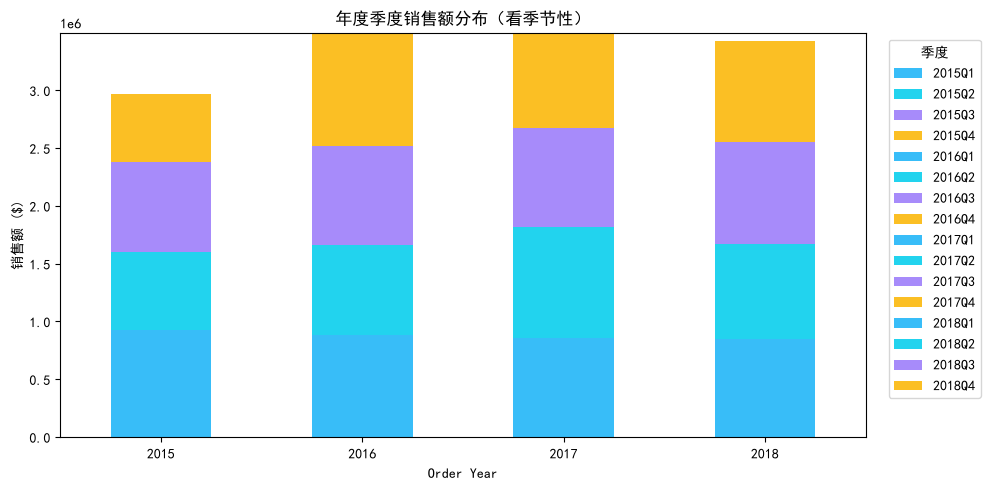

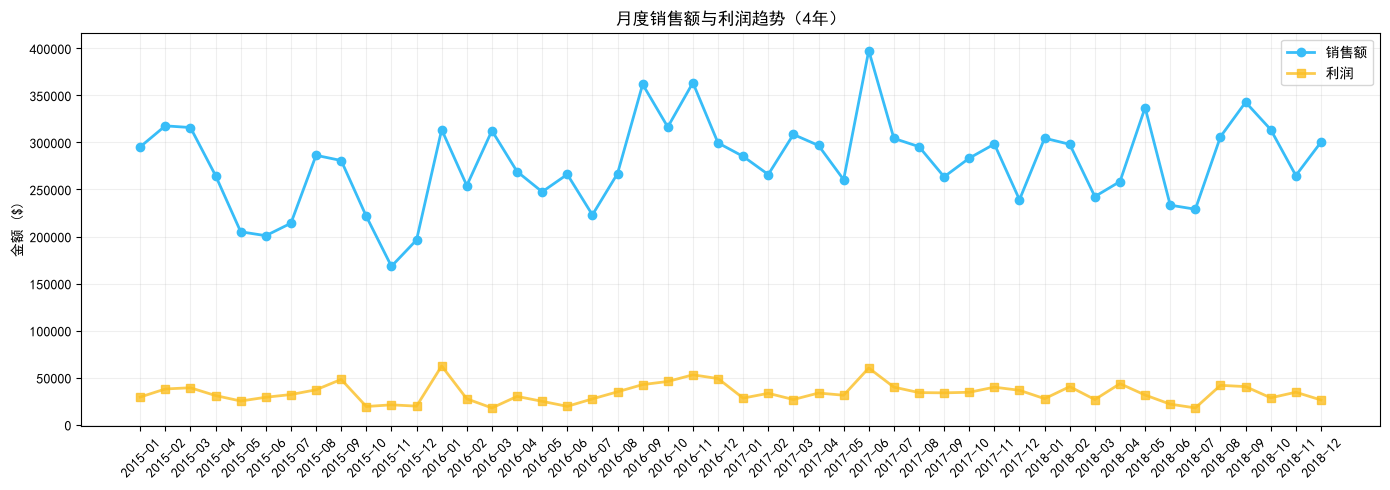


【各月总销售额（4年累计）】
Order Month
9     1248682.0
1     1198569.0
3     1179290.0
8     1154795.0
2     1135628.0
10    1134794.0
6     1097931.0
11    1094867.0
4     1089031.0
5     1050022.0
12    1035248.0
7      970458.0
Name: 月总销售额, dtype: float64


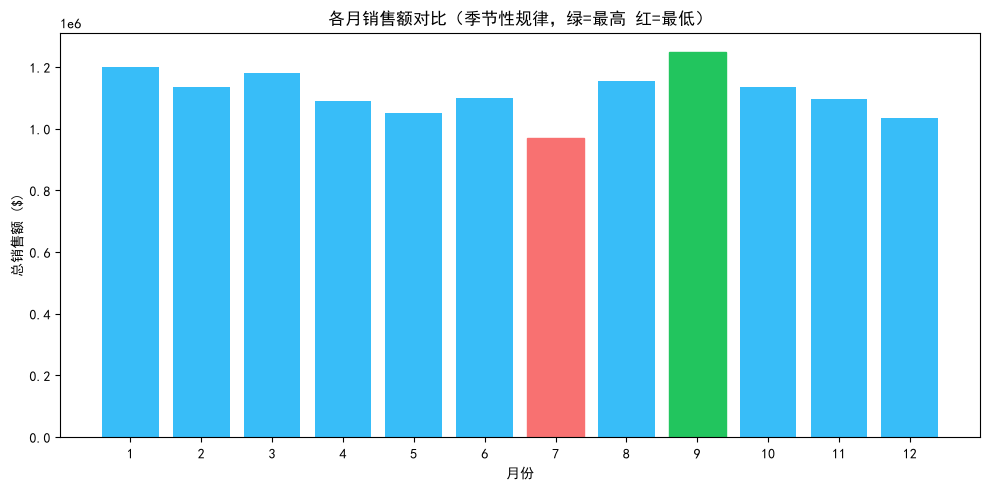


【周内各天订单分布】
  周一: 销售额 $1,909,860, 订单数 1378
  周二: 销售额 $1,921,747, 订单数 1376
  周三: 销售额 $1,983,423, 订单数 1428
  周四: 销售额 $1,801,380, 订单数 1404
  周五: 销售额 $2,075,623, 订单数 1459
  周六: 销售额 $1,768,104, 订单数 1375
  周日: 销售额 $1,929,177, 订单数 1380


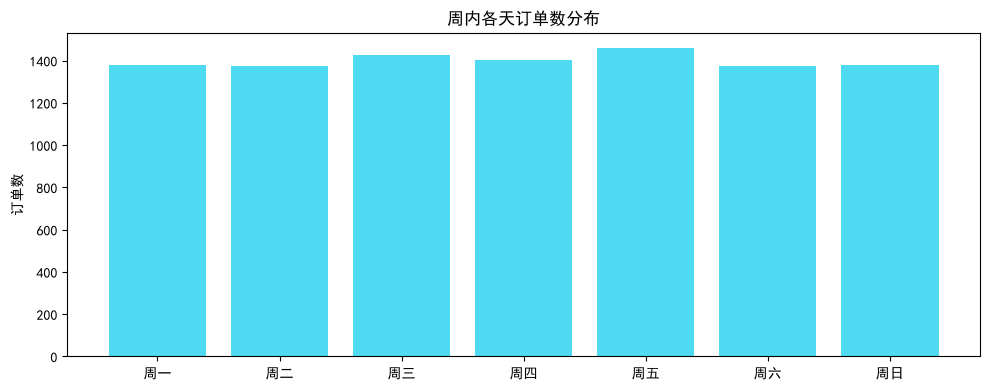


【最近12个月同比增速】
Order Date
2018-01-31     6.8
2018-02-28    12.1
2018-03-31   -21.4
2018-04-30   -12.9
2018-05-31    29.4
2018-06-30   -41.3
2018-07-31   -24.7
2018-08-31     3.6
2018-09-30    30.1
2018-10-31    10.7
2018-11-30   -11.2
2018-12-31    25.6
Freq: ME, Name: Sales, dtype: float64


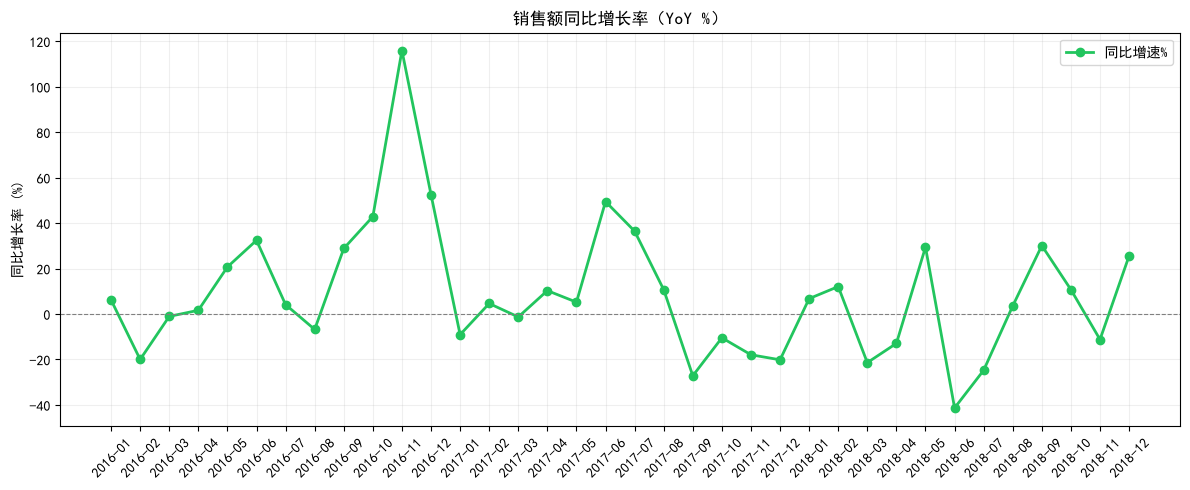

In [14]:
'''
增长趋势：业务是逐年增长还是下滑？年增长率大概多少？
季节性：哪个月/季度是旺季？哪个是淡季？Q4占全年多少比例？
波动性：月度波动大不大？有没有明显的周期性？
同比环比：最近一年增长怎么样？有没有放缓的迹象？
'''
# ==========================================
# 4.1 年度趋势（看业务增长还是下滑）
# ==========================================
yearly = df.groupby('Order Year').agg(
    销售额=('Sales','sum'),
    利润=('Profit','sum'),
    订单数=('Order ID','nunique'),
    客户数=('Customer ID','nunique')
).round(2)
yearly['利润率'] = (yearly['利润'] / yearly['销售额'] * 100).round(1)
yearly['销售额同比'] = yearly['销售额'].pct_change().round(3) * 100
yearly['利润同比'] = yearly['利润'].pct_change().round(3) * 100
print("【年度趋势】")
print(yearly)

# 年度销售额+利润双轴图
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(yearly.index, yearly['销售额'], color='#38bdf8', alpha=0.7, label='销售额')
ax1.set_xlabel('年份')
ax1.set_ylabel('销售额 ($)', color='#38bdf8')
ax1.tick_params(axis='y', labelcolor='#38bdf8')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['利润'], color='#fbbf24', marker='o', linewidth=2, label='利润')
ax2.set_ylabel('利润 ($)', color='#fbbf24')
ax2.tick_params(axis='y', labelcolor='#fbbf24')

plt.title('年度销售额 vs 利润趋势')
fig.tight_layout()
plt.savefig('eda_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4.2 季度分析（看季节性）
# ==========================================
# 各年各季度销售额
quarterly_sales = df.groupby(['Order Year', 'Order Quarter'])['Sales'].sum().unstack()
print("\n【各年各季度销售额】")
print(quarterly_sales.round(0))

# 季度占比（每年的Q1-Q4各占当年多少）
quarterly_pct = quarterly_sales.div(quarterly_sales.sum(axis=1), axis=0) * 100
print("\n【季度占比（%）】")
print(quarterly_pct.round(1))

# 堆积柱状图
quarterly_sales.plot(kind='bar', stacked=True, figsize=(10,5),
                     color=['#38bdf8','#22d3ee','#a78bfa','#fbbf24'])
plt.title('年度季度销售额分布（看季节性）')
plt.ylabel('销售额 ($)')
plt.xticks(rotation=0)
plt.legend(title='季度', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_quarterly_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4.3 月度趋势（看更细的波动）
# ==========================================
monthly_sales = df.groupby('Order MonthStr')['Sales'].sum()
monthly_profit = df.groupby('Order MonthStr')['Profit'].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o',
         color='#38bdf8', linewidth=2, label='销售额')
plt.plot(monthly_sales.index, monthly_profit.values, marker='s',
         color='#fbbf24', linewidth=2, label='利润', alpha=0.8)
plt.title('月度销售额与利润趋势（4年）')
plt.ylabel('金额 ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4.4 月均对比（把所有年的同月放一起看季节性规律）
# ==========================================
month_avg = df.groupby('Order Month').agg(
    月均销售额=('Sales','mean'),
    月总销售额=('Sales','sum')
)
print("\n【各月总销售额（4年累计）】")
print(month_avg['月总销售额'].sort_values(ascending=False).round(0))

plt.figure(figsize=(10,5))
bars = plt.bar(month_avg.index, month_avg['月总销售额'],
               color=['#38bdf8' if i < 12 else '#22d3ee' for i in range(12)])
# 高亮最高和最低月
max_idx = month_avg['月总销售额'].idxmax()
min_idx = month_avg['月总销售额'].idxmin()
bars[max_idx-1].set_color('#22c55e')  # 最高月绿色
bars[min_idx-1].set_color('#f87171')  # 最低月红色

plt.title('各月销售额对比（季节性规律，绿=最高 红=最低）')
plt.xlabel('月份')
plt.ylabel('总销售额 ($)')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('eda_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4.5 周分布（看一周内哪天订单多）
# ==========================================
df['Order Weekday'] = df['Order Date'].dt.dayofweek  # 0=周一, 6=周日
weekday_names = ['周一','周二','周三','周四','周五','周六','周日']
weekday_sales = df.groupby('Order Weekday')['Sales'].sum()
weekday_orders = df.groupby('Order Weekday')['Order ID'].nunique()

print("\n【周内各天订单分布】")
for i, name in enumerate(weekday_names):
    if i in weekday_sales.index:
        print(f"  {name}: 销售额 ${weekday_sales[i]:,.0f}, 订单数 {weekday_orders[i]}")

plt.figure(figsize=(10,4))
plt.bar(weekday_names, [weekday_orders.get(i,0) for i in range(7)],
        color='#22d3ee', alpha=0.8)
plt.title('周内各天订单数分布')
plt.ylabel('订单数')
plt.tight_layout()
plt.savefig('eda_weekday_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 4.6 同比环比计算（面试高频）
# ==========================================
monthly = df.set_index('Order Date').resample('ME')['Sales'].sum()
# 同比：去年同月
yoy = (monthly.pct_change(12) * 100).dropna()
# 环比：上月
mom = (monthly.pct_change(1) * 100).dropna()

print("\n【最近12个月同比增速】")
print(yoy.tail(12).round(1))

plt.figure(figsize=(12,5))
plt.plot(yoy.index.strftime('%Y-%m'), yoy.values, marker='o',
         color='#22c55e', linewidth=2, label='同比增速%')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('销售额同比增长率（YoY %）')
plt.ylabel('同比增长率 (%)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('eda_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()


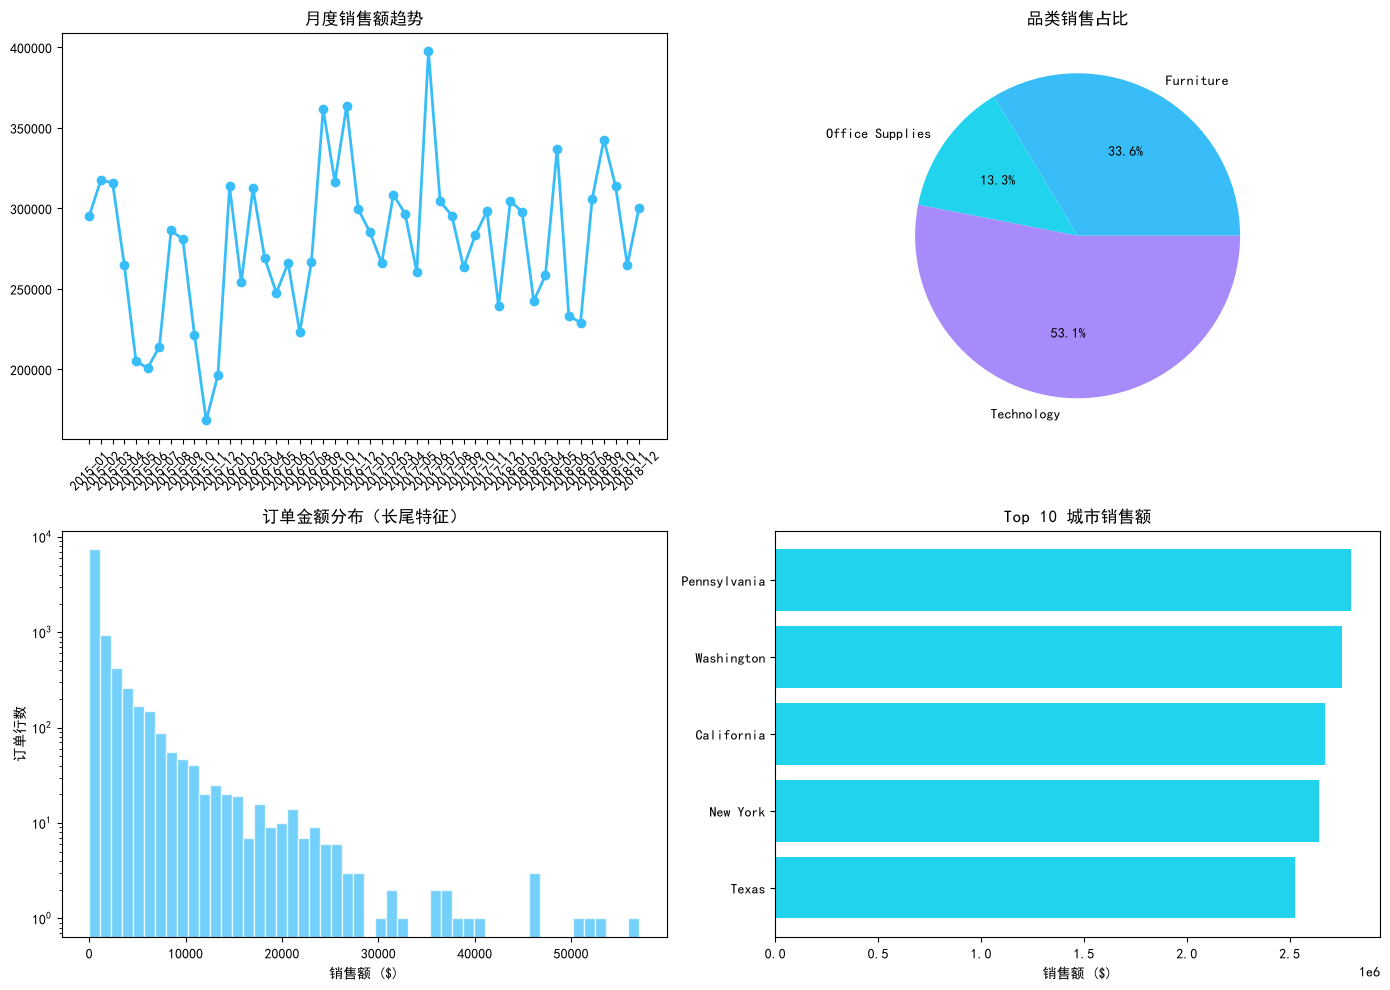

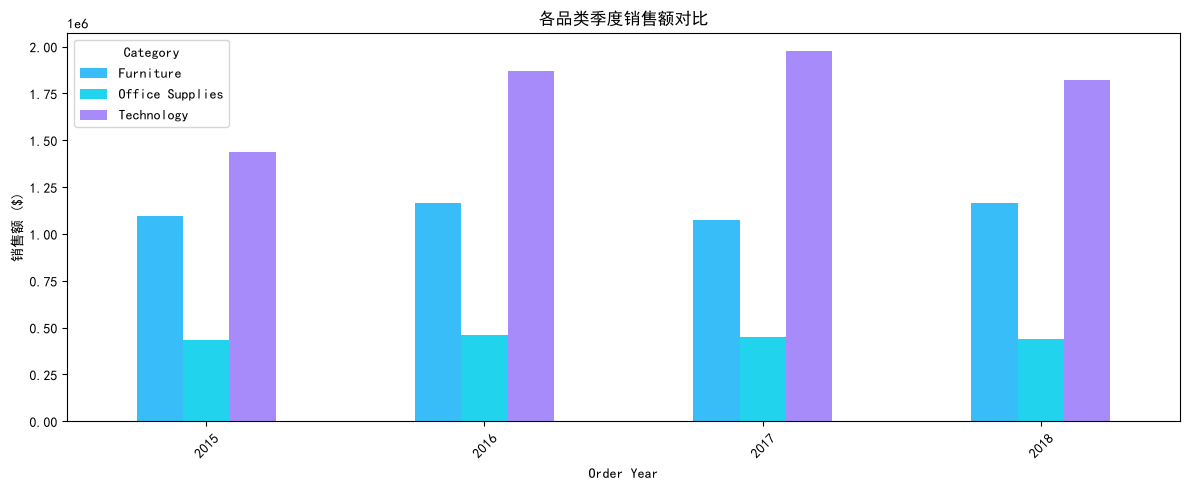

In [10]:
#画图分布分析
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1: 月度销售额趋势
monthly = df.groupby('Order MonthStr')['Sales'].sum()
axes[0,0].plot(monthly.index, monthly.values, marker='o', color='#38bdf8', linewidth=2)
axes[0,0].set_title('月度销售额趋势')
axes[0,0].tick_params(axis='x', rotation=45)

# 图2: 品类销售额占比（饼图）
cat_sales = df.groupby('Category')['Sales'].sum()
axes[0,1].pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%',
              colors=['#38bdf8','#22d3ee','#a78bfa'])
axes[0,1].set_title('品类销售占比')

# 图3: 销售额分布（直方图 - 看长尾）
axes[1,0].hist(df['Sales'], bins=50, color='#38bdf8', alpha=0.7, edgecolor='white')
axes[1,0].set_title('订单金额分布（长尾特征）')
axes[1,0].set_xlabel('销售额 ($)')
axes[1,0].set_ylabel('订单行数')
axes[1,0].set_yscale('log')  # 用对数坐标看长尾

# 图4: Top10 城市销售额
top_cities = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1,1].barh(top_cities.index[::-1], top_cities.values[::-1], color='#22d3ee')
axes[1,1].set_title('Top 10 城市销售额')
axes[1,1].set_xlabel('销售额 ($)')

plt.tight_layout()
plt.savefig('eda_4plots.png', dpi=150, bbox_inches='tight')
plt.show()

# === 补充：季度对比柱状图 ===
quarterly = df.groupby(['Order Year', 'Category'])['Sales'].sum().unstack()
quarterly.plot(kind='bar', figsize=(12,5), color=['#38bdf8','#22d3ee','#a78bfa'])
plt.title('各品类季度销售额对比')
plt.ylabel('销售额 ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

相关系数矩阵:
           Sales  Quantity  Discount  Profit  Ship Days
Sales      1.000     0.218    -0.121   0.577     -0.005
Quantity   0.218     1.000     0.009   0.138     -0.002
Discount  -0.121     0.009     1.000  -0.073     -0.002
Profit     0.577     0.138    -0.073   1.000     -0.007
Ship Days -0.005    -0.002    -0.002  -0.007      1.000


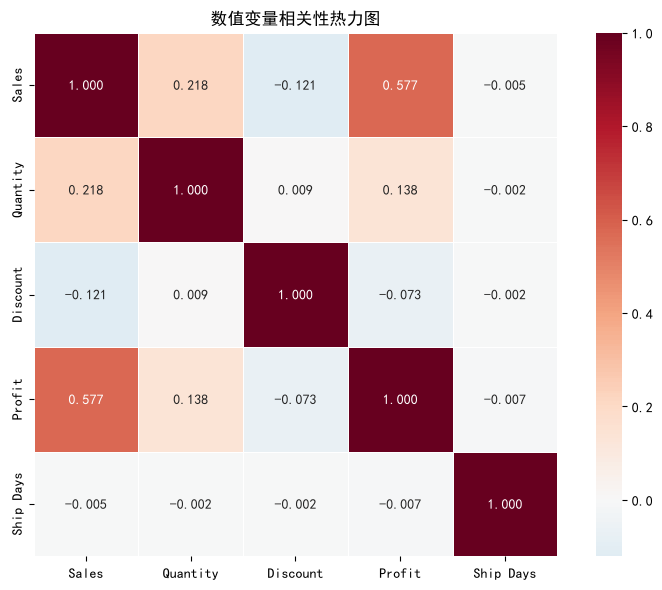

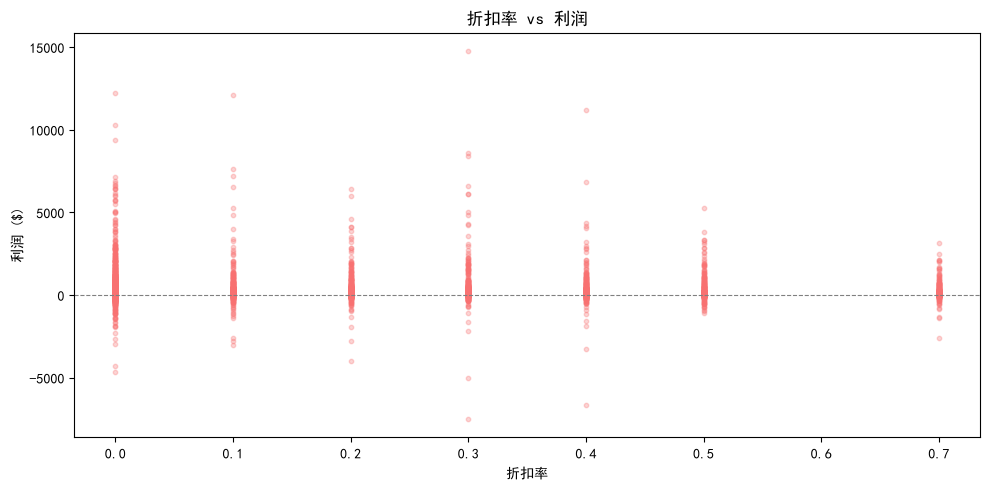

In [12]:
#相关性分析
"""
   销售额 ↔ 销量：正相关，很正常
   折扣 ↔ 利润：负相关，折扣越高利润越低，甚至亏损 —— 这是后续定价策略的重要依据
   发货天数 ↔ 销售额：看看有没有关系？如果发货快销售额高，说明物流体验影响购买
"""
# === 相关系数矩阵 ===
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']
corr = df[numeric_cols].corr()
print("相关系数矩阵:")
print(corr.round(3))

# === 热力图 ===
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('数值变量相关性热力图')
plt.tight_layout()
plt.savefig('eda_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# === 折扣 vs 利润 散点图 ===
plt.figure(figsize=(10, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10, c='#f87171')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('折扣率')
plt.ylabel('利润 ($)')
plt.title('折扣率 vs 利润')
plt.tight_layout()
plt.savefig('eda_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ===== 生成EDA分析报告 =====
report_html = f"""
<!DOCTYPE html>
<html><head><meta charset="utf-8">
<title>EDA分析报告 - 智能库存分析系统</title>
<style>
  body {{ font-family: -apple-system, "PingFang SC", sans-serif;
         max-width: 900px; margin: 0 auto; padding: 30px; line-height: 1.8; }}
  h1 {{ color: #0c4a6e; border-bottom: 3px solid #0ea5e9; padding-bottom: 10px; }}
  h2 {{ color: #0c4a6e; margin-top: 28px; border-left: 4px solid #0ea5e9; padding-left: 12px; }}
  .insight {{ background: #f0f9ff; border-left: 4px solid #0ea5e9;
              padding: 14px 18px; margin: 12px 0; border-radius: 6px; }}
  .insight strong {{ color: #0c4a6e; }}
  img {{ max-width: 100%; border-radius: 8px; margin: 12px 0;
         box-shadow: 0 2px 10px rgba(0,0,0,0.1); }}
  .kpi-row {{ display: flex; gap: 16px; flex-wrap: wrap; margin: 16px 0; }}
  .kpi {{ background: #f8fafc; border: 1px solid #e2e8f0;
          border-radius: 8px; padding: 14px 20px; flex: 1; min-width: 140px; }}
  .kpi-val {{ font-size: 22px; font-weight: bold; color: #0c4a6e; }}
  .kpi-lbl {{ font-size: 12px; color: #64748b; }}
</style>
</head><body>

<h1>📊 EDA探索性数据分析报告</h1>
<p style="color:#64748b">项目：智能库存分析与补货模拟系统 | 数据集：Superstore Sales（模拟） | 时间：2015-2018</p>

<h2>一、核心指标总览</h2>
<div class="kpi-row">
  <div class="kpi"><div class="kpi-val">${total_sales:,.0f}</div><div class="kpi-lbl">总销售额</div></div>
  <div class="kpi"><div class="kpi-val">${total_profit:,.0f}</div><div class="kpi-lbl">总利润</div></div>
  <div class="kpi"><div class="kpi-val">{overall_margin:.1f}%</div><div class="kpi-lbl">整体利润率</div></div>
  <div class="kpi"><div class="kpi-val">{df['Order ID'].nunique():,}</div><div class="kpi-lbl">订单数</div></div>
</div>

<h2>二、关键业务洞察</h2>
<div class="insight">
  <p><strong>1. 市场格局</strong>：{top_region}地区贡献最大，占总销售额的{top_region_pct}%；
  {top_cat}品类占比最高，达{top_cat_pct}%。</p>
  <p><strong>2. 盈利结构</strong>：整体利润率{overall_margin:.1f}%，
  {cat_margin.index[0]}品类利润率最高（{cat_margin.iloc[0]}%），
  {cat_margin.index[-1]}品类最低（{cat_margin.iloc[-1]}%），盈利差距明显。</p>
  <p><strong>3. 季节性规律</strong>：Q4占全年销售额的{q4_ratio}%，
  {peak_month}月为销售峰值，{low_month}月为淡季，
  库存策略需考虑季节性波动，旺季前提前备货。</p>
  <p><strong>4. 帕累托效应</strong>：Top 20% 的产品贡献了{pareto_pct}%的销售额，
  符合二八法则，为ABC分类管理提供了数据支撑。</p>
</div>

<h2>三、时间维度分析</h2>
<img src="eda_yearly_trend.png" alt="年度趋势">
<img src="eda_monthly_trend.png" alt="月度趋势">
<img src="eda_monthly_seasonality.png" alt="季节性">

<h2>四、品类与地区分布</h2>
<img src="eda_distribution.png" alt="分布图">
<img src="eda_category_yearly.png" alt="品类年度对比">

<h2>五、相关性分析</h2>
<img src="eda_corr.png" alt="热力图">
<img src="eda_discount_profit.png" alt="折扣利润">

<h2>六、下一步计划</h2>
<ul>
  <li>✅ EDA探索性数据分析 — 已完成</li>
  <li>⬜ ABC分类 — 按销售额/利润对SKU分级管理</li>
  <li>⬜ 需求预测 — 移动平均与指数平滑</li>
  <li>⬜ 安全库存与EOQ模型</li>
  <li>⬜ 补货策略模拟与Dashboard</li>
</ul>

</body></html>
"""

with open('EDA分析报告.html', 'w', encoding='utf-8') as f:
    f.write(report_html)
print("✅ EDA分析报告已生成：EDA分析报告.html")

✅ EDA分析报告已生成：EDA分析报告.html


In [19]:
# 在EDA那个notebook的最后一个cell运行
df.to_pickle('df_cleaned.pkl')